<a href="https://colab.research.google.com/github/CristianoCoelhoSilva/Python/blob/master/Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import numpy as np
import pandas as pd
import seaborn
import matplotlib
import pydotplus
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso#Loading the dataset
from sklearn.metrics import confusion_matrix
from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
from sklearn import preprocessing

In [91]:
#Arquivo completo
df = pd.read_csv(r"https://raw.githubusercontent.com/CristianoCoelhoSilva/Python/master/Python/covid_limit.csv")

df.drop(["ENTUBADO"], axis="columns", inplace=True)

In [92]:
##Fazendo o holdout

X = df.drop(['INTERNADO','IDADE'], axis = "columns")
y = df.INTERNADO

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 13)

## Script

In [122]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron

pipeline_estendido = Pipeline([
    ("pre_process", make_column_transformer(
                              (Pipeline([
                                  ('imputer', KNNImputer(n_neighbors = 3)),
                                  ('scaler', StandardScaler())
                              ]) , make_column_selector(dtype_include = np.number)),
                              (Pipeline([
                                  ("imputer", SimpleImputer(strategy = 'most_frequent', fill_value = "unknown")),
                                  ("encoder", OneHotEncoder(handle_unknown = 'ignore'))
                              ]), make_column_selector(dtype_exclude = np.number))
                          )),
    ##("knn", KNeighborsClassifier())
    ('tree', DecisionTreeClassifier())
    ##('Random_forest',RandomForestClassifier())
])

In [ ]:
import pprint as pp

pp.pprint(sorted(pipeline_estendido.get_params().keys()))

In [123]:
#Knn
#param_grid_estendido = {
#    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
#    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
#    "knn__n_neighbors": range(1, 2)
#}

#Decision Tree
param_grid_estendido = {
    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
    "tree__min_samples_leaf": range(1, 3)
}

#Random_forest
#param_grid_estendido = {
#    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
#    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
#    "Random_forest__n_estimators": range(1, 10)
#}


In [124]:
classificador_estendido = GridSearchCV(estimator = pipeline_estendido,
                                       param_grid = param_grid_estendido,
                                       scoring = "roc_auc",
                                       cv = 5,
                                       refit = True)

In [ ]:
classificador_estendido.fit(X_train, y_train)

In [126]:
print("Melhor parâmetro do modelo knn: ")
print(classificador_estendido.best_params_)

print("Desempenho médio no fold de teste: ")
print(np.mean(classificador_estendido.cv_results_['mean_test_score']))

print("\nDesvio padrão: ")
#dúvida: np.std ou np.mean?
print(np.mean(classificador_estendido.cv_results_['std_test_score']))

Melhor parâmetro do modelo knn: 
{'pre_process__pipeline-1__imputer__n_neighbors': 2, 'pre_process__pipeline-2__imputer__strategy': 'constant', 'tree__min_samples_leaf': 2}
Desempenho médio no fold de teste: 
0.49163763902164576

Desvio padrão: 
0.05814918421662056


In [127]:
y_pred = classificador_estendido.predict(X_test)

accuracy_score(y_pred = y_pred,
               y_true = y_test)

0.9266666666666666

In [128]:
from sklearn.metrics import confusion_matrix

roc_auc_score(y_pred, y_test)

0.5225694444444444

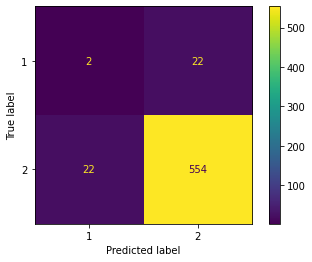

In [132]:
from sklearn.metrics import plot_confusion_matrix

plot_confusion_matrix(classificador_estendido, X_test, y_test, values_format = '')

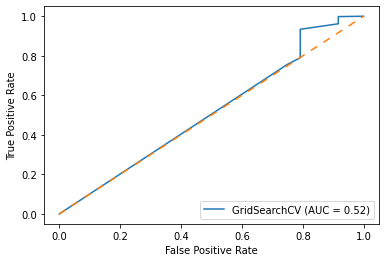

In [130]:
from sklearn.metrics import plot_roc_curve
plot_roc_curve(classificador_estendido, X_test, y_test)
identity_line, = plt.plot([0,1],
                          [0,1])
identity_line.set_dashes([5, 5, 5, 5])